# Stage 7: Model Evaluation & Comparison

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_recall_curve, average_precision_score,
                              accuracy_score, precision_score, recall_score)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load test data and models
X_test        = pd.read_csv('./data/processed/X_test.csv')
X_test_scaled = pd.read_csv('./data/processed/X_test_scaled.csv')
y_test        = pd.read_csv('./data/processed/y_test.csv').squeeze()

best_rf  = joblib.load('./models/random_forest.pkl')
best_svm = joblib.load('./models/svm.pkl')
best_xgb = joblib.load('./models/xgboost.pkl')

models = {
    'Random Forest': (best_rf, X_test),
    'SVM':           (best_svm, X_test_scaled),
    'XGBoost':       (best_xgb, X_test)
}
print('All models and test data loaded ✓')

All models and test data loaded ✓


## 7.1 Classification Reports

In [3]:
results = {}

for name, (model, X_t) in models.items():
    y_pred  = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    
    results[name] = {
        'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy':  accuracy_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_proba)
    }
    
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred, target_names=['Non-Potable', 'Potable']))


  Random Forest
              precision    recall  f1-score   support

 Non-Potable       0.83      0.78      0.81       400
     Potable       0.69      0.75      0.72       256

    accuracy                           0.77       656
   macro avg       0.76      0.77      0.76       656
weighted avg       0.77      0.77      0.77       656


  SVM
              precision    recall  f1-score   support

 Non-Potable       0.68      0.68      0.68       400
     Potable       0.49      0.49      0.49       256

    accuracy                           0.60       656
   macro avg       0.58      0.58      0.58       656
weighted avg       0.60      0.60      0.60       656


  XGBoost
              precision    recall  f1-score   support

 Non-Potable       0.83      0.80      0.81       400
     Potable       0.71      0.74      0.72       256

    accuracy                           0.78       656
   macro avg       0.77      0.77      0.77       656
weighted avg       0.78      0.78      

## 7.2 Model Comparison Table

In [4]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']:.4f}",
        'F1-Score':  f"{r['f1']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'ROC-AUC':   f"{r['auc']:.4f}"
    } for name, r in results.items()
}).T

print('=== MODEL COMPARISON ===')
print(comparison_df.to_string())

# Highlight best model
best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n🏆 Best Model by AUC: {best_model_name} ({results[best_model_name]["auc"]:.4f})')

=== MODEL COMPARISON ===
              Accuracy F1-Score Precision  Recall ROC-AUC
Random Forest   0.7698   0.7178    0.6882  0.7500  0.8683
SVM             0.6037   0.4922    0.4922  0.4922  0.6164
XGBoost         0.7774   0.7214    0.7052  0.7383  0.8762

🏆 Best Model by AUC: XGBoost (0.8762)


## 7.3 Confusion Matrices

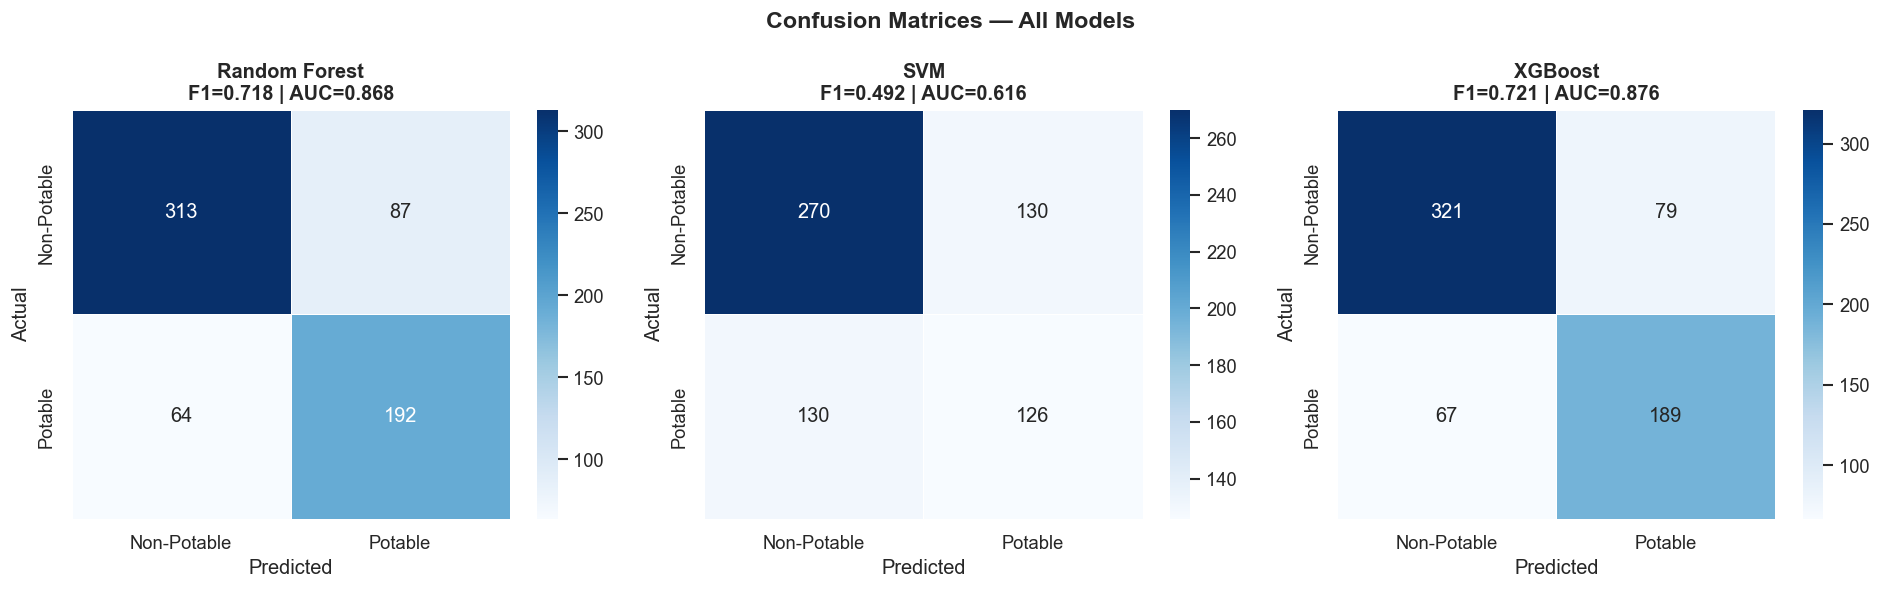

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Potable', 'Potable'],
                yticklabels=['Non-Potable', 'Potable'],
                linewidths=0.5)
    ax.set_title(f'{name}\nF1={r["f1"]:.3f} | AUC={r["auc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

## 7.4 ROC Curves

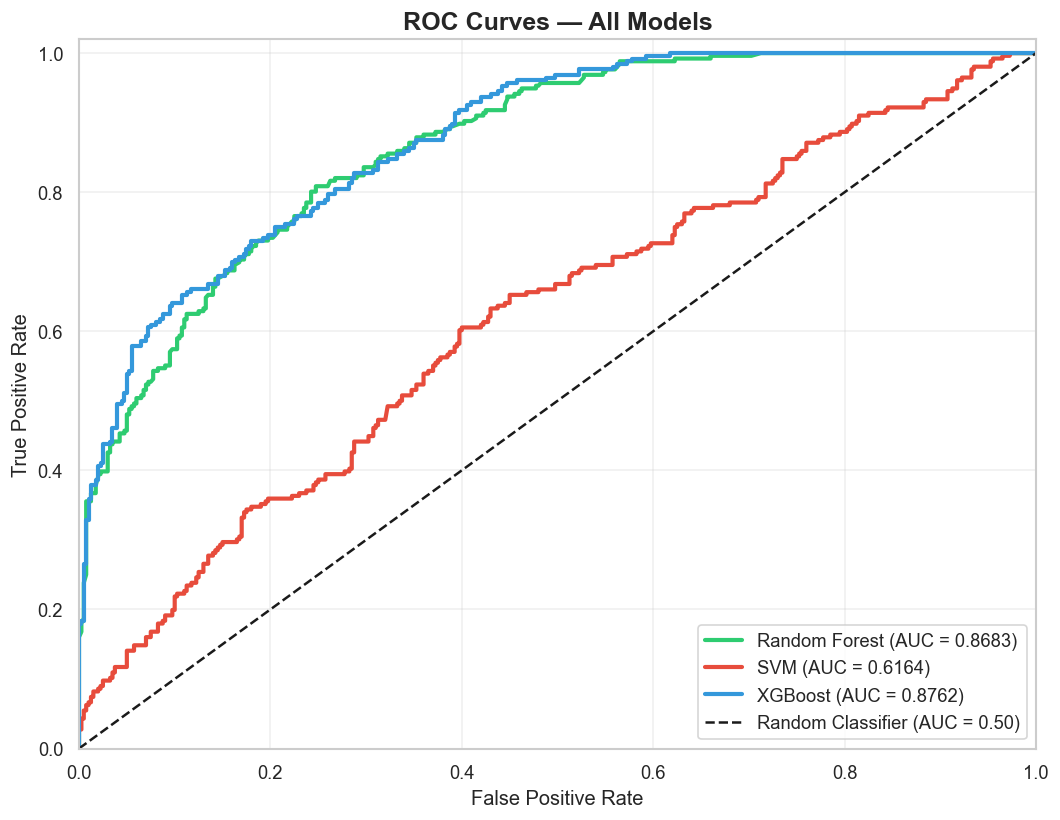

In [6]:
plt.figure(figsize=(9, 7))
colors = ['#2ecc71', '#e74c3c', '#3498db']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name} (AUC = {r["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./data/processed/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 7.5 Precision-Recall Curves

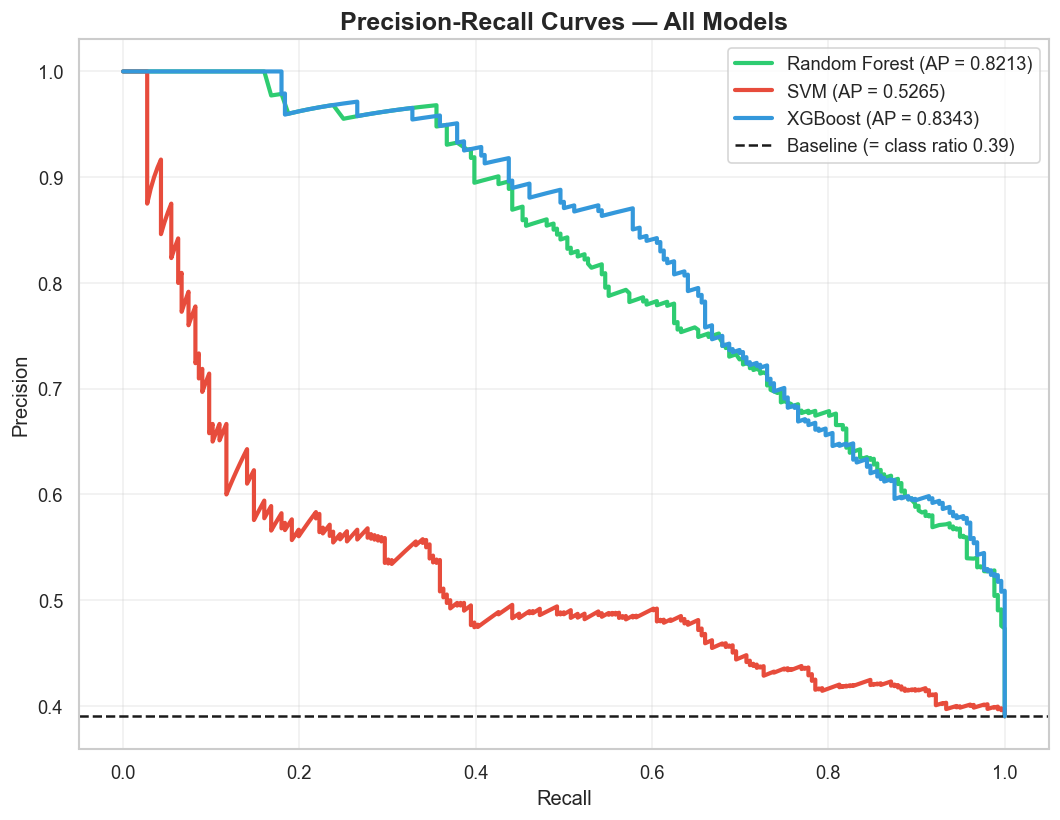

In [7]:
plt.figure(figsize=(9, 7))

for (name, r), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, r['y_proba'])
    ap = average_precision_score(y_test, r['y_proba'])
    plt.plot(recall, precision, color=color, lw=2.5,
             label=f'{name} (AP = {ap:.4f})')

baseline = y_test.mean()
plt.axhline(baseline, color='k', linestyle='--', lw=1.5,
            label=f'Baseline (= class ratio {baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./data/processed/precision_recall_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 7.6 Save Best Model

In [9]:
# Save best model as the production model
best_model_name = max(results, key=lambda k: results[k]['auc'])
best_model_obj, _ = models[best_model_name]

joblib.dump(best_model_obj, './models/best_model.pkl')
joblib.dump(best_model_name, './models/best_model_name.pkl')

print(f'✓ Best model ({best_model_name}) saved as models/best_model.pkl')
print(f'  Accuracy: {results[best_model_name]["accuracy"]:.4f}')
print(f'  F1-Score: {results[best_model_name]["f1"]:.4f}')
print(f'  ROC-AUC:  {results[best_model_name]["auc"]:.4f}')

✓ Best model (XGBoost) saved as models/best_model.pkl
  Accuracy: 0.7774
  F1-Score: 0.7214
  ROC-AUC:  0.8762
